In [1]:
# Run this cell to work in colab
import sys, os
from pathlib import Path

# Colab-specific setup
if 'google.colab' in sys.modules:
    if not os.path.exists("ioer-conference-2026-haclathon"):
        !git clone -q https://github.com/ioer-dresden/ioer-conference-2026-haclathon.git
    %cd -q ioer-conference-2026-haclathon/notebooks

# Install required packages
pyexec = sys.executable
!../py/modules/pkginstall.sh "{pyexec}" geopandas matplotlib requests

Installed geopandas 1.1.4.
Installed matplotlib 3.11.1.
requests already installed (version 2.34.2).


# 🌿 Urban Green Cooling Benifits with ioerDATA: From API to Insight

* **Authors**: Marzan Tasnim Oyshi (IOER) & Maria Nieswand (IOER)
* **Topics**: Urban Green Infrastructure, Climate Regulation, Ecosystem Services, Open Data Re-use, Reproducible Research
*  **Badges**: ![ioerDATA](https://img.shields.io/badge/Data-ioerDATA-green?style=flat-square) ![Dataverse API](https://img.shields.io/badge/Access-Dataverse_API-blueviolet?style=flat-square) ![FAIR Data](https://img.shields.io/badge/Principle-FAIR_Data-brightgreen?style=flat-square) ![Colab](https://img.shields.io/badge/Colab-Tested-yellow?style=flat-square&logo=googlecolab&logoColor=white) ![Jupyter](https://img.shields.io/badge/Jupyter4NFDI-Ready-orange?style=flat-square&logo=jupyter)
```{admonition} Summary
:class: hint
How much can urban green infrastructure contribute to climate regulation in German cities and how many people benefit from it?

In this chapter, we reuse the openly published ioerDATA replication package **Climate Regulation in Cities** to explore a national ecosystem-service indicator for urban climate regulation.

We will:

- access an openly published replication package,
- explore spatial indicators for German cities,
- investigate cooling capacity provided by urban green infrastructure,
- compare cooling capacity with population benefit,
- create reproducible maps and visualisations,
- and explore how the data could support urban planning.

The aim is to demonstrate how published research data can be **reused, explored, and extended**.
```

---

## 1. Why does urban green matter?

Cities are particularly vulnerable to heat.

Buildings, sealed surfaces, roads, and other artificial surfaces can store heat and contribute to the **urban heat island effect**. Green infrastructure can counteract some of these effects through shading, evapotranspiration, and other local climate-regulation processes.

Urban green infrastructure includes elements such as:

- trees,
- parks,
- urban forests,
- gardens,
- grass and vegetated surfaces,
- and other green spaces.

But simply asking **"How green is a city?"** is not enough.

For climate adaptation, we are also interested in:

> **Where does urban green provide cooling capacity, and how many people may benefit from it?**

This notebook explores that question using an openly available research dataset.

## 2. From publication to reusable research data

The analysis is based on the ioerDATA replication package:

> **Replication package for: Climate Regulation in Cities**

The dataset provides a national indicator of local climate regulation by urban green infrastructure for **165 German cities with more than 50,000 inhabitants**.

It contains information on:

- urban green infrastructure,
- cooling capacity,
- population,
- and the proportion of inhabitants benefiting from climate-regulating ecosystem services.

The replication package accompanies the publication:

*Assessment and Monitoring of Local Climate Regulation in Cities by Green Infrastructure — A National Ecosystem Service Indicator for Germany.*

This gives us an opportunity to move beyond simply reading a scientific publication.

Instead, we can directly inspect and reuse the underlying research data.

## Reproducibility first

A scientific figure is much more useful when we can understand:

1. **where the data came from,**
2. **how it was processed,**
3. **which indicators were created,**
4. **and how the final visualisation was produced.**

This notebook therefore keeps the complete workflow visible and executable.

The same data can then be reused for questions that were not necessarily part of the original publication.

## 3. Access the replication package

The dataset is published through **ioerDATA**, which is based on Dataverse.

Instead of manually downloading the GeoPackage, we can retrieve it programmatically.

This is useful because the source of the data becomes part of the analysis itself.

### Setup

Import the libraries needed for this chapter

In [17]:
#import cell
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import requests

from pathlib import Path
from getpass import getpass

import geopandas as gpd
import matplotlib.pyplot as plt

import matplotlib.patheffects as pe

from tqdm.auto import tqdm

print("Installed libraries ✓")

Installed libraries ✓


### Check the dataset contents

Before downloading the data, we first query the ioerDATA API to see which files are included in the replication package.

The request may take a few moments. A loading indicator will appear while the metadata is being retrieved.

In [14]:
# DOI of the ioerDATA replication package
dataset_doi = "doi:10.71830/AFW3N3"

# Build the Dataverse API URL for the dataset
api_url = (
    "https://data.fdz.ioer.de/api/datasets/:persistentId/"
    f"?persistentId={dataset_doi}"
)

# Show a loading message while requesting the metadata
print("⏳ Retrieving dataset information from ioerDATA...")

# Request metadata from the ioerDATA Dataverse API
response = requests.get(api_url, timeout=60)
response.raise_for_status()

# Convert the API response to JSON
metadata = response.json()

# Extract the files from the latest dataset version
files = metadata["data"]["latestVersion"]["files"]

# Confirm that the request has finished
print(f"✓ Done! Found {len(files)} files:\n")

# Display the available filenames
for item in files:
    print(f"  • {item['dataFile']['filename']}")

⏳ Retrieving dataset information from ioerDATA...
✓ Done! Found 14 files:

  • Assessment_and_Monitoring_of_Local_Climate_Regulation.pdf
  • Climate_regulation_in_cities_as_an_ecosystem_service_German.pdf
  • Cooling_Capacity_2018_buffered.gdb.zip
  • Documentation.md
  • Figure_1_Urban_green_Infrastructure_Syrbe_KLu-04.png
  • Map_1_Climate_regulation_Air_Photo.jpg
  • Map_2_Climate_regulation_Tree_Cover.jpg
  • Map_3_Climate_regulation_Population.jpg
  • Map_4_Climate_regulation_Cooling_Capacity.jpg
  • Map_5_Cities_cooling_capacity.jpg
  • Map_6_Cities_inhabitants_cooling_capacity.jpg
  • README.md
  • Stadtklima_Skript.py
  • climate_regulation_in_cities.gpkg


## 3. Download the replication package

The replication package is published on **ioerDATA** and can be accessed through the Dataverse API.

While many files are publicly available, some are **restricted** and require authentication. By creating a free **ioerDATA account**, you can generate a **personal API token** that allows this notebook to securely access all files your account is authorized to use.

**Already have an ioerDATA account?** Simply log in.  
**New to ioerDATA?** Sign up for an account and follow the steps below to create your personal API token.

![ioerDATA login](../resources/dataverse.png "ioerDATA login")
![ioerDATA API](../resources/dataverse_api.png "ioerDATA API")

> ⚠️ **Keep your API token private.** Never save it in the notebook or commit it to GitHub.

In [15]:
# ioerDATA Dataverse address and dataset DOI
base_url = "https://data.fdz.ioer.de"
persistent_id = "doi:10.71830/AFW3N3"

# Ask for the personal API token securely.
# The entered token will not be displayed in the notebook.
api_token = getpass("🔑 Paste your ioerDATA API token: ")
headers = {"X-Dataverse-key": api_token}

print("\n⏳ Authenticating and retrieving dataset information...")

# Request metadata for the latest version of the dataset
url = f"{base_url}/api/datasets/:persistentId/"

response = requests.get(
    url,
    params={"persistentId": persistent_id},
    headers=headers,
    timeout=60
)

# Stop with a clear error if the request was unsuccessful
response.raise_for_status()

# Extract the list of files from the API response
metadata = response.json()
files = metadata["data"]["latestVersion"]["files"]

# Create a folder for the downloaded files
data_dir = Path("data/raw")
data_dir.mkdir(parents=True, exist_ok=True)

# Confirm that everything is ready for the download
print(f"✓ Ready! {len(files)} files found.")
print(f"📁 Files will be stored in: {data_dir.resolve()}")

🔑 Paste your ioerDATA API token:  ········



⏳ Authenticating and retrieving dataset information...
✓ Ready! 14 files found.
📁 Files will be stored in: /home/jovyan/work/hackathon-ioer-conference-2026/notebooks/data/raw


### Download the dataset files

The files are now downloaded to a local `data/raw` folder.

A progress bar shows the download status for each file. Restricted files are downloaded only if your ioerDATA account has permission.

If you are running this notebook in **Google Colab**, you can also package the downloaded files into a ZIP archive and download them to your computer.

In [19]:
# Show where files will be stored
print(f"📁 Download folder:\n{data_dir.resolve()}\n")

# Show the complete list before downloading anything
print(f"📦 {len(files)} files found in the replication package:\n")

for i, item in enumerate(files, start=1):
    file = item["dataFile"]
    filename = file["filename"]
    access = "restricted" if item.get("restricted") else "public"

    print(f"{i:>2}. {filename} ({access})")

print("\n⬇ Starting downloads...\n")

# Download files one by one
for i, item in enumerate(files, start=1):
    file = item["dataFile"]
    filename = file["filename"]
    output = data_dir / filename
    access = "restricted" if item.get("restricted") else "public"

    print(f"\n[{i}/{len(files)}] {filename} ({access})")

    # Request the file as a stream so it can be downloaded in chunks
    response = requests.get(
        f"{base_url}/api/access/datafile/{file['id']}",
        headers=headers,
        stream=True,
        timeout=120
    )

    # Skip restricted files if the account does not have permission
    if response.status_code in (401, 403):
        print("⏭ Skipped — no permission")
        continue

    # Stop if another download error occurs
    response.raise_for_status()

    # Get the expected file size, if provided by the server
    total_size = int(response.headers.get("content-length", 0))

    # Save the file while showing download progress
    with open(output, "wb") as f:
        with tqdm(
            total=total_size,
            unit="B",
            unit_scale=True,
            unit_divisor=1024,
            desc="Downloading",
            leave=True
        ) as progress:

            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    progress.update(len(chunk))

    print(f"✓ Saved to: {output.resolve()}")

# Final summary
print("\n✅ Download process complete.")
print(f"📁 Available files are stored in:\n{data_dir.resolve()}")

📁 Download folder:
/home/jovyan/work/hackathon-ioer-conference-2026/notebooks/data/raw

📦 14 files found in the replication package:

 1. Assessment_and_Monitoring_of_Local_Climate_Regulation.pdf (public)
 2. Climate_regulation_in_cities_as_an_ecosystem_service_German.pdf (public)
 3. Cooling_Capacity_2018_buffered.gdb.zip (public)
 4. Documentation.md (public)
 5. Figure_1_Urban_green_Infrastructure_Syrbe_KLu-04.png (public)
 6. Map_1_Climate_regulation_Air_Photo.jpg (public)
 7. Map_2_Climate_regulation_Tree_Cover.jpg (public)
 8. Map_3_Climate_regulation_Population.jpg (public)
 9. Map_4_Climate_regulation_Cooling_Capacity.jpg (public)
10. Map_5_Cities_cooling_capacity.jpg (public)
11. Map_6_Cities_inhabitants_cooling_capacity.jpg (public)
12. README.md (public)
13. Stadtklima_Skript.py (public)
14. climate_regulation_in_cities.gpkg (restricted)

⬇ Starting downloads...


[1/14] Assessment_and_Monitoring_of_Local_Climate_Regulation.pdf (public)


Downloading: 0.00B [00:00, ?B/s]

✓ Saved to: /home/jovyan/work/hackathon-ioer-conference-2026/notebooks/data/raw/Assessment_and_Monitoring_of_Local_Climate_Regulation.pdf

[2/14] Climate_regulation_in_cities_as_an_ecosystem_service_German.pdf (public)


Downloading: 0.00B [00:00, ?B/s]

✓ Saved to: /home/jovyan/work/hackathon-ioer-conference-2026/notebooks/data/raw/Climate_regulation_in_cities_as_an_ecosystem_service_German.pdf

[3/14] Cooling_Capacity_2018_buffered.gdb.zip (public)


...

✓ Saved to: /home/jovyan/work/hackathon-ioer-conference-2026/notebooks/data/raw/README.md

[13/14] Stadtklima_Skript.py (public)


Downloading: 0.00B [00:00, ?B/s]

✓ Saved to: /home/jovyan/work/hackathon-ioer-conference-2026/notebooks/data/raw/Stadtklima_Skript.py

[14/14] climate_regulation_in_cities.gpkg (restricted)


Downloading: 0.00B [00:00, ?B/s]

✓ Saved to: /home/jovyan/work/hackathon-ioer-conference-2026/notebooks/data/raw/climate_regulation_in_cities.gpkg

✅ Download process complete.
📁 Available files are stored in:
/home/jovyan/work/hackathon-ioer-conference-2026/notebooks/data/raw


In [5]:
for item in files:
    file = item["dataFile"]
    filename = file["filename"]
    output = data_dir / filename

    response = requests.get(
        f"{base_url}/api/access/datafile/{file['id']}",
        headers=headers,
        stream=True
    )

    if response.status_code in (401, 403):
        print(f"Skipped: {filename} — no permission")
        continue

    response.raise_for_status()

    with open(output, "wb") as f:
        for chunk in response.iter_content(1024 * 1024):
            if chunk:
                f.write(chunk)

    access = "restricted" if item.get("restricted") else "public"
    print(f"Downloaded: {filename} ({access})")

Downloaded: Assessment_and_Monitoring_of_Local_Climate_Regulation.pdf (public)
Downloaded: Climate_regulation_in_cities_as_an_ecosystem_service_German.pdf (public)
Downloaded: Cooling_Capacity_2018_buffered.gdb.zip (public)
Downloaded: Documentation.md (public)
Downloaded: Figure_1_Urban_green_Infrastructure_Syrbe_KLu-04.png (public)
Downloaded: Map_1_Climate_regulation_Air_Photo.jpg (public)
Downloaded: Map_2_Climate_regulation_Tree_Cover.jpg (public)
Downloaded: Map_3_Climate_regulation_Population.jpg (public)
Downloaded: Map_4_Climate_regulation_Cooling_Capacity.jpg (public)
Downloaded: Map_5_Cities_cooling_capacity.jpg (public)
Downloaded: Map_6_Cities_inhabitants_cooling_capacity.jpg (public)
Downloaded: README.md (public)
Downloaded: Stadtklima_Skript.py (public)
Downloaded: climate_regulation_in_cities.gpkg (restricted)


## FAIR Data in Practice

This replication package illustrates how the **FAIR principles** can support reproducible research:

- **Findable** — the dataset has a persistent DOI and searchable metadata.
- **Accessible** — data and metadata can be accessed through ioerDATA and its Dataverse API. Restricted files remain available through controlled access.
- **Interoperable** — spatial data is provided in standard formats such as GeoPackage.
- **Reusable** — documentation, metadata and provenance allow the data to be understood and used beyond the original study.

> **FAIR does not necessarily mean open.**  
> Restricted data can still be FAIR when access conditions are clearly described and authorised users can access the data through a transparent process.

## 4. Load the spatial data

The main spatial dataset is stored as a GeoPackage. We load it with GeoPandas and inspect the available indicators before mapping them.

In [23]:
# Define the path to the downloaded GeoPackage
gpkg_path = data_dir / "climate_regulation_in_cities.gpkg"

# Load the spatial dataset as a GeoDataFrame
gdf = gpd.read_file(gpkg_path)

# Display basic information about the dataset
print(f"Features: {len(gdf)}")
print(f"CRS: {gdf.crs}")

# Preview the first five rows
gdf.head()

Features: 165
CRS: EPSG:3035


,AGS,GEN,NUTS,Shape_Leng,Shape_Area,Pop_Benefit_Percent,geometry
0,09563000,Fürth,DE253,49209.551437,6.334375e+07,49.550707,"MULTIPOLYGON (((4392577.758 2936451.016, 43926..."
1,09162000,München,DE212,118084.194383,3.108342e+08,70.270877,"MULTIPOLYGON (((4432133.707 2774479.63, 443212..."
2,09461000,Bamberg,DE241,44492.667416,5.464215e+07,77.048748,"MULTIPOLYGON (((4388203.406 2978639.586, 43882..."
3,09262000,Passau,DE222,61360.769487,6.956591e+07,78.069768,"MULTIPOLYGON (((4570163.06 2838978.815, 457018..."
4,09564000,Nürnberg,DE254,153997.952475,1.866370e+08,46.746620,"MULTIPOLYGON (((4401927.814 2917518.273, 44019..."


This is the checkpoint where you identify the exact columns for:

>city name, cooling capacity, population benefit

In [24]:
# List all attribute columns available in the spatial dataset
gdf.columns.tolist()

['AGS',
 'GEN',
 'NUTS',
 'Shape_Leng',
 'Shape_Area',
 'Pop_Benefit_Percent',
 'geometry']

## 5. Where is climate-regulation capacity high?

Urban green infrastructure provides different levels of cooling capacity across German cities.

Mapping the indicator helps reveal where climate-regulation potential is comparatively high or low.

In [27]:
# Prepare the data and geographic context for the map

# Select the indicator to visualize and the column containing city names
value_col = "Pop_Benefit_Percent"
name_col = "GEN"

# Reproject the city data to WGS84 for mapping
gdf_wgs = gdf.to_crs("EPSG:4326")

# Load country boundaries from Natural Earth
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# Select Germany to provide geographic context
germany = world[world["NAME"] == "Germany"]

# Select major cities to label without overcrowding the map
major_cities = {
    "Berlin", "Hamburg", "München", "Dresden",
    "Köln", "Leipzig", "Frankfurt am Main", "Bremen"
}

# Keep only the selected cities for map labels
labels = gdf_wgs[gdf_wgs[name_col].isin(major_cities)]
print ("Map Context Prepared!")

Map Context Prepared!


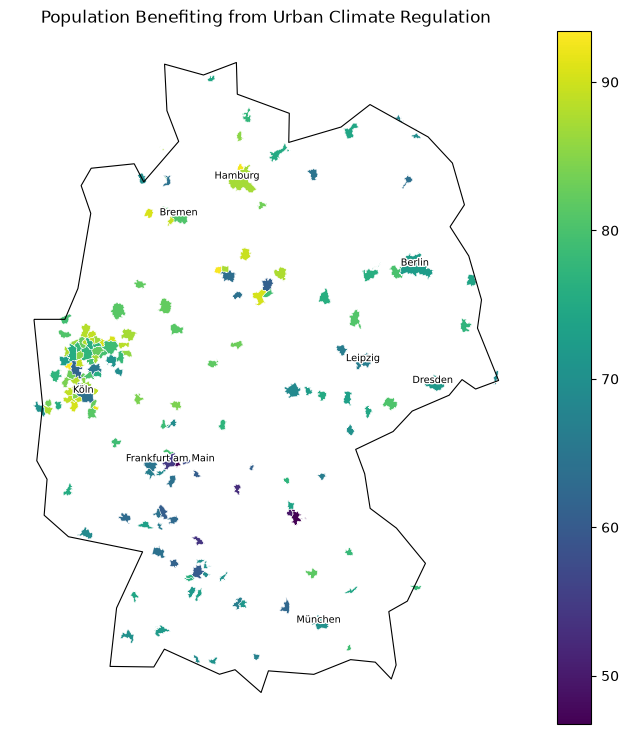

In [28]:
# Create the map and set the figure size
fig, ax = plt.subplots(figsize=(9, 9))

# Map the percentage of population benefiting from urban climate regulation
gdf_wgs.plot(
    column=value_col,
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)

# Add the German national boundary for geographic context
germany.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.8
)

# Add labels for selected major cities
for _, row in labels.iterrows():

    # Find a suitable point inside each city geometry for the label
    p = row.geometry.representative_point()

    # Add the city name
    txt = ax.text(
        p.x,
        p.y,
        row[name_col],
        fontsize=7,
        ha="center"
    )

    # Add a white outline to make labels easier to read
    txt.set_path_effects([
        pe.withStroke(linewidth=2, foreground="white")
    ])

# Add a descriptive title and remove map axes
ax.set_title("Population Benefiting from Urban Climate Regulation")
ax.set_axis_off()

# Display the finished map
plt.show()

### What does the map show?

The indicator represents the **share of inhabitants benefiting from the cooling effect of urban green infrastructure**.

The map reveals that this benefit varies between German cities. This shifts the focus from simply asking *where green infrastructure exists* to asking:

> **How effectively does urban green infrastructure provide climate-regulation benefits to people?**

## 6. From replication to exploration

Reproducing the indicator map is only the starting point.

Because the replication package provides reusable spatial data, we can explore additional questions:

- Which cities show particularly high or low population benefit?
- How do cities compare with each other?
- What might these differences mean for urban green planning?

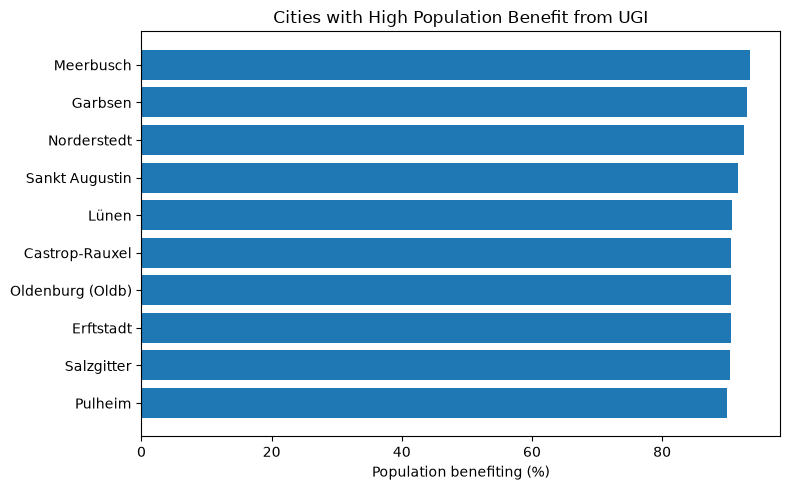

In [29]:
# Select the 10 cities with the highest population benefit
# and sort them for a clear horizontal bar chart
top = gdf.nlargest(10, value_col).sort_values(value_col)

# Create the figure
fig, ax = plt.subplots(figsize=(8, 5))

# Compare the population benefit across the selected cities
ax.barh(
    top[name_col],
    top[value_col]
)

# Add a descriptive axis label and title
ax.set_xlabel("Population benefiting (%)")
ax.set_title("Cities with High Population Benefit from UGI")

# Adjust spacing so labels are not cut off
plt.tight_layout()

# Display the finished chart
plt.show()

## Try it yourself

Open data makes it possible to move beyond reproduction.

Try changing the analysis:

- Find the cities with the **lowest** population benefit.
- Select a city you know and compare it with others.
- Explore another file from the replication package.

> **Replication reproduces evidence. Reuse creates opportunities for new questions.**

## Conclusion

This example moves from:

**open research data → spatial indicator → city comparison → planning question**

Urban green infrastructure is not only about the amount of green space. Its relevance also depends on the **climate-regulation service it provides and the population that benefits from it**.

The ioerDATA replication package makes this evidence accessible for reproduction, exploration, and further research.

## Acknowledgements

This contribution builds on the broader [**ioerDATA training materials**](https://github.com/ioer-dresden/jupyter-book-ioerdata) developed at IOER.

The author gratefully acknowledges **Cruickshank, Claudia** for feedback and refinement & **Dunkel, Alexander** for technical support and earlier training resources.